# Product Master-Data Field Classifier

## 📈 Results at a glance

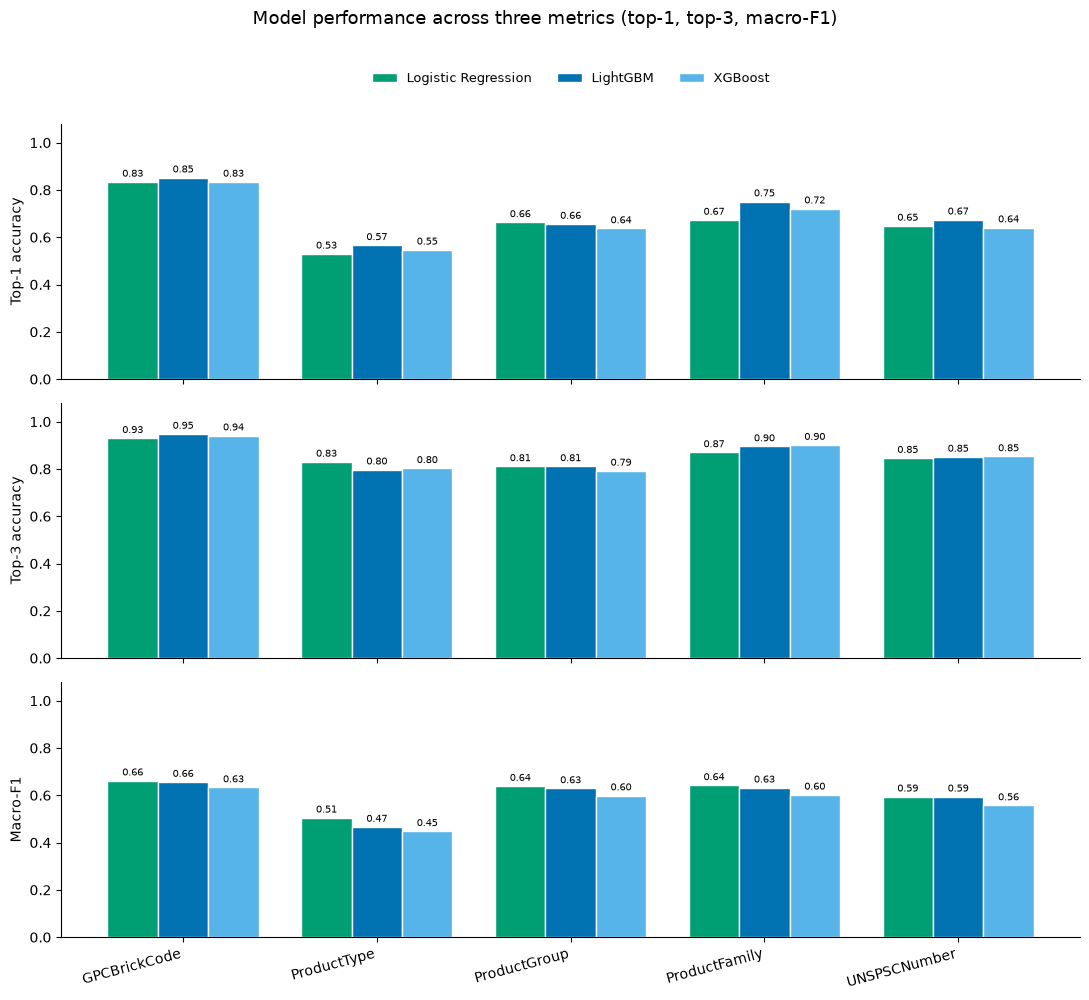

In [1]:
# imports, config, seed
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
from pathlib import Path
import numpy as np, pandas as pd
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import f1_score, multilabel_confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
import lightgbm as lgb, xgboost as xgb
import matplotlib.pyplot as plt

SEED = 42; np.random.seed(SEED)
DATA = Path("data") / "product_master_sample_523.csv"
TEXT_COLS = ["ProductShortName", "ProductShortName1", "ProductShortName2", "FunctionalName",
             "VariantDescription", "TradeItemUnitDescription", "ProductDescription"]
CAT_COLS = ["BrandName", "SubBrandName", "IsMedical"]
TARGETS = ["GPCBrickCode", "ProductType", "ProductGroup", "ProductFamily", "UNSPSCNumber"]
N_SPLITS, MIN_COUNT = 4, 6

## Data & Features

In [2]:
def load_data():
    """Read the CSV, fill blanks with NONE, fuse the 7 text columns into one."""
    df = pd.read_csv(DATA, dtype=str, keep_default_na=False)
    for c in TEXT_COLS + CAT_COLS:
        df[c] = df[c].fillna("").replace("", "NONE")           # missing -> its own "NONE" category
    df["text"] = df[TEXT_COLS].agg(" ".join, axis=1).str.strip()  # fuse the text columns
    return df

def get_xy(df, target):
    """Rows that actually have this field — plus the target to predict."""
    sub = df[df[target].str.strip() != ""].reset_index(drop=True)  # keep rows with a label for this field
    return sub, sub[target].astype(str)

def make_sparse(train_df, test_df):                            # word+char TF-IDF + one-hot cats, FIT ON TRAIN ONLY
    """Word + char TF-IDF and one-hot cats — fit on train only, no leakage."""
    vw = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
    vc = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2)
    oh = OneHotEncoder(handle_unknown="ignore")
    Xtr = hstack([vw.fit_transform(train_df["text"]), vc.fit_transform(train_df["text"]), oh.fit_transform(train_df[CAT_COLS])]).tocsr()
    Xte = hstack([vw.transform(test_df["text"]), vc.transform(test_df["text"]), oh.transform(test_df[CAT_COLS])]).tocsr()
    return Xtr, Xte

df = load_data()

## Cross - validation

In [3]:
def keep_set(y, mc=MIN_COUNT):
    """Which labels appear often enough (>= MIN_COUNT) to model?"""
    vc = y.value_counts(); return set(vc[vc >= mc].index)     # labels frequent enough to keep

def merge_rare(y, keep):
    """Fold every too-rare label into a single 'RARE' bucket."""
    return y.where(y.isin(keep), "RARE")                      # fold rare labels into one bucket

def _splitter(y_strat):                                       # stratify when possible, else KFold (guards singletons)
    """4-fold split — stratified when classes allow, else plain KFold."""
    if y_strat.value_counts().min() >= N_SPLITS:
        return StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED).split(np.zeros(len(y_strat)), y_strat)
    return KFold(N_SPLITS, shuffle=True, random_state=SEED).split(np.zeros(len(y_strat)))

def topk_hits(proba, classes, y_true, k):                    # is the true label among the model's top-k guesses?
    """Did the true label make the model's top-k shortlist?"""
    top = np.asarray(classes).astype(str)[np.argsort(-proba, axis=1)[:, :k]]
    return np.array([yt in row for yt, row in zip(y_true, top)])

def cross_validate(fit_predict, sub, y_raw):
    """Leakage-safe out-of-fold scoring: top-1, top-3, macro-F1, rare merged per fold."""
    y_strat = merge_rare(y_raw, keep_set(y_raw, N_SPLITS)); n = len(y_raw); t1 = t3 = 0.0; fold_f1 = []
    for tr, te in _splitter(y_strat):
        keep = keep_set(y_raw.iloc[tr])                       # rare-merge decided on TRAIN fold only
        ytr = merge_rare(y_raw.iloc[tr], keep).reset_index(drop=True)
        yte = merge_rare(y_raw.iloc[te], keep).values.astype(str)
        proba, classes = fit_predict(sub.iloc[tr].reset_index(drop=True), sub.iloc[te].reset_index(drop=True), ytr)
        classes = np.asarray(classes).astype(str); pred = classes[np.argmax(proba, 1)]
        t1 += (pred == yte).sum(); t3 += topk_hits(proba, classes, yte, min(3, proba.shape[1])).sum()
        fold_f1.append(f1_score(yte, pred, average="macro"))
    return dict(top1=t1 / n, top3=t3 / n, macroF1=float(np.mean(fold_f1)))

## Confusion matrices

In [ ]:
def confusion_fig(fit_predict, name, field="GPCBrickCode"):
    import textwrap
    sub, y = get_xy(df, field); yt, yp = [], []
    for tr, te in _splitter(merge_rare(y, keep_set(y, N_SPLITS))):     # OOF predictions; all 7 real classes kept
        proba, classes = fit_predict(sub.iloc[tr].reset_index(drop=True), sub.iloc[te].reset_index(drop=True),
                                     y.iloc[tr].reset_index(drop=True))
        yt += list(y.iloc[te].astype(str)); yp += list(np.asarray(classes).astype(str)[np.argmax(proba, 1)])
    labels = sorted(set(yt) | set(yp))
    full = [(l.split(" - ", 1)[1] if " - " in l else l) for l in labels]           # FULL class names (no truncation)
    mcm = multilabel_confusion_matrix(yt, yp, labels=labels)                        # per class: [[TN, FP], [FN, TP]]
    LBL = [["correctly\nskipped", "false\nalarm"], ["missed", "caught"]]            # [actual][predicted]
    COL = [[(0.93, 0.93, 0.93), (0.99, 0.82, 0.80)], [(0.99, 0.82, 0.80), (0.72, 0.88, 0.72)]]  # grey / red / green
    n = len(labels); ncols = min(n, 4); nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 3.4 * nrows + 0.8), squeeze=False)
    for i, ax in enumerate(axes.flat):                                             # one 2x2 per class, side-by-side
        if i >= n:
            ax.set_axis_off(); continue
        M = mcm[i]
        ax.imshow([[COL[r][c] for c in range(2)] for r in range(2)])               # colour by MEANING, not by count
        for r in range(2):
            for c in range(2):
                ax.text(c, r, f"{LBL[r][c]}\n{int(M[r, c])}", ha="center", va="center", fontsize=8)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["not", "is"], fontsize=7)
        ax.set_yticks([0, 1]); ax.set_yticklabels(["not", "is"], fontsize=7)
        ax.set_xlabel("predicted", fontsize=7); ax.set_ylabel("actual", fontsize=7)
        ax.set_title(textwrap.fill(full[i], 18), fontsize=8)
    acc = sum(int(M[1, 1]) for M in mcm) / len(yt)                                 # overall correct on this field
    rec = [(full[i], (int(mcm[i][1, 1]) / s if (s := int(mcm[i][1, 1] + mcm[i][1, 0])) else 0.0),
            int(mcm[i][1, 1]), int(mcm[i][1, 1] + mcm[i][1, 0])) for i in range(n)]
    best = max([t for t in rec if t[3] >= 20] or rec, key=lambda t: t[1])
    verdict = (f"Verdict: {acc:.0%} correct overall — confidently auto-fills the high-volume categories "
               f"(e.g. {best[0]} at {best[1]:.0%}), while lighter-sampled ones route to a steward for a quick confirm, "
               f"so every product still lands right.")
    fig.suptitle(f"{name} — per class: green = correct, red = error (counts shown)", fontsize=12, y=0.99)
    fig.text(0.5, 0.006, verdict, ha="center", va="bottom", fontsize=9.5, style="italic", wrap=True)
    fig.tight_layout(rect=[0, 0.045, 1, 0.95], h_pad=3.4, w_pad=1.5)
    plt.show()

## Model - LightGBM

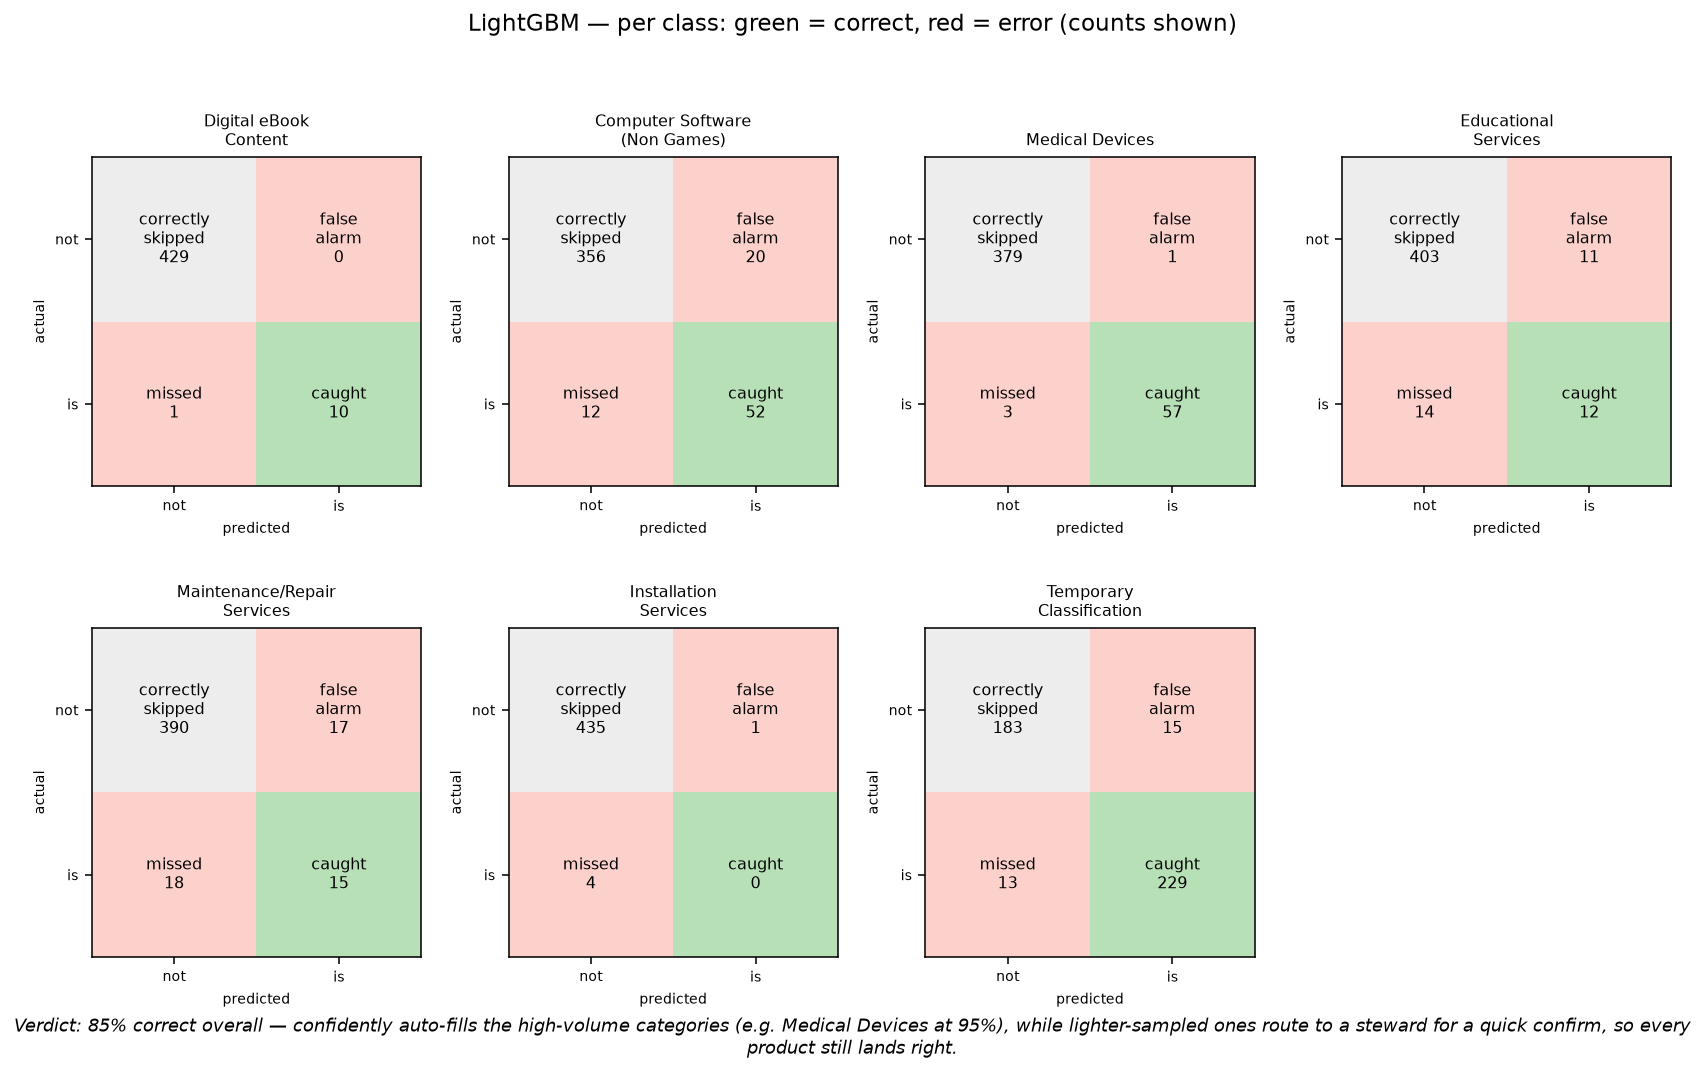

In [5]:
def fit_predict_lgbm(train_df, test_df, y_train):
    """Train LightGBM on sparse features; return per-class probs and class names."""
    Xtr, Xte = make_sparse(train_df, test_df); le = LabelEncoder().fit(y_train)
    m = lgb.LGBMClassifier(objective="multiclass", num_class=len(le.classes_), n_estimators=400, learning_rate=0.05,
                           num_leaves=31, min_child_samples=5, colsample_bytree=0.5, subsample=0.8, subsample_freq=1,
                           reg_lambda=1.0, class_weight="balanced", random_state=SEED, n_jobs=-1, verbose=-1)
    m.fit(Xtr, le.transform(y_train))
    return m.predict_proba(Xte), le.classes_.astype(str)

confusion_fig(fit_predict_lgbm, "LightGBM")

## Model - Logistic Regression

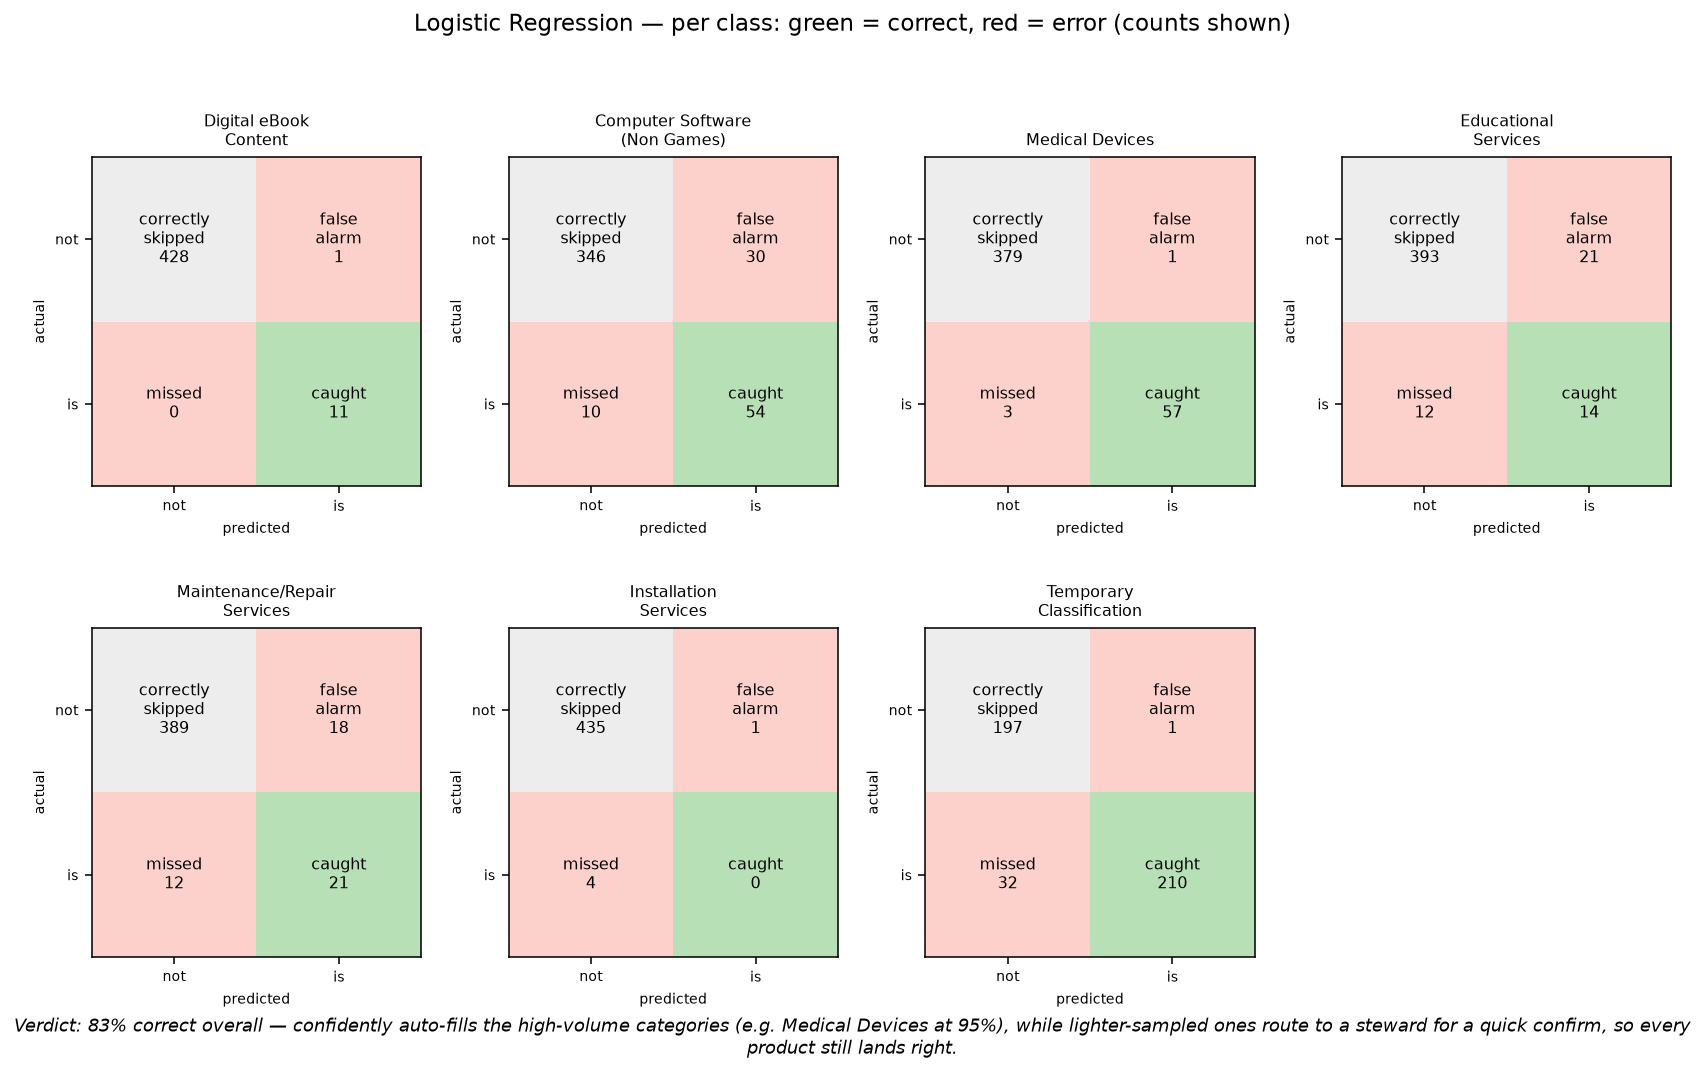

In [6]:
def fit_predict_lr(train_df, test_df, y_train):
    """Train the recommended Logistic Regression; return probs and class names."""
    Xtr, Xte = make_sparse(train_df, test_df)
    m = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr, y_train)
    return m.predict_proba(Xte), m.classes_.astype(str)

confusion_fig(fit_predict_lr, "Logistic Regression")

## Model - XGBoost

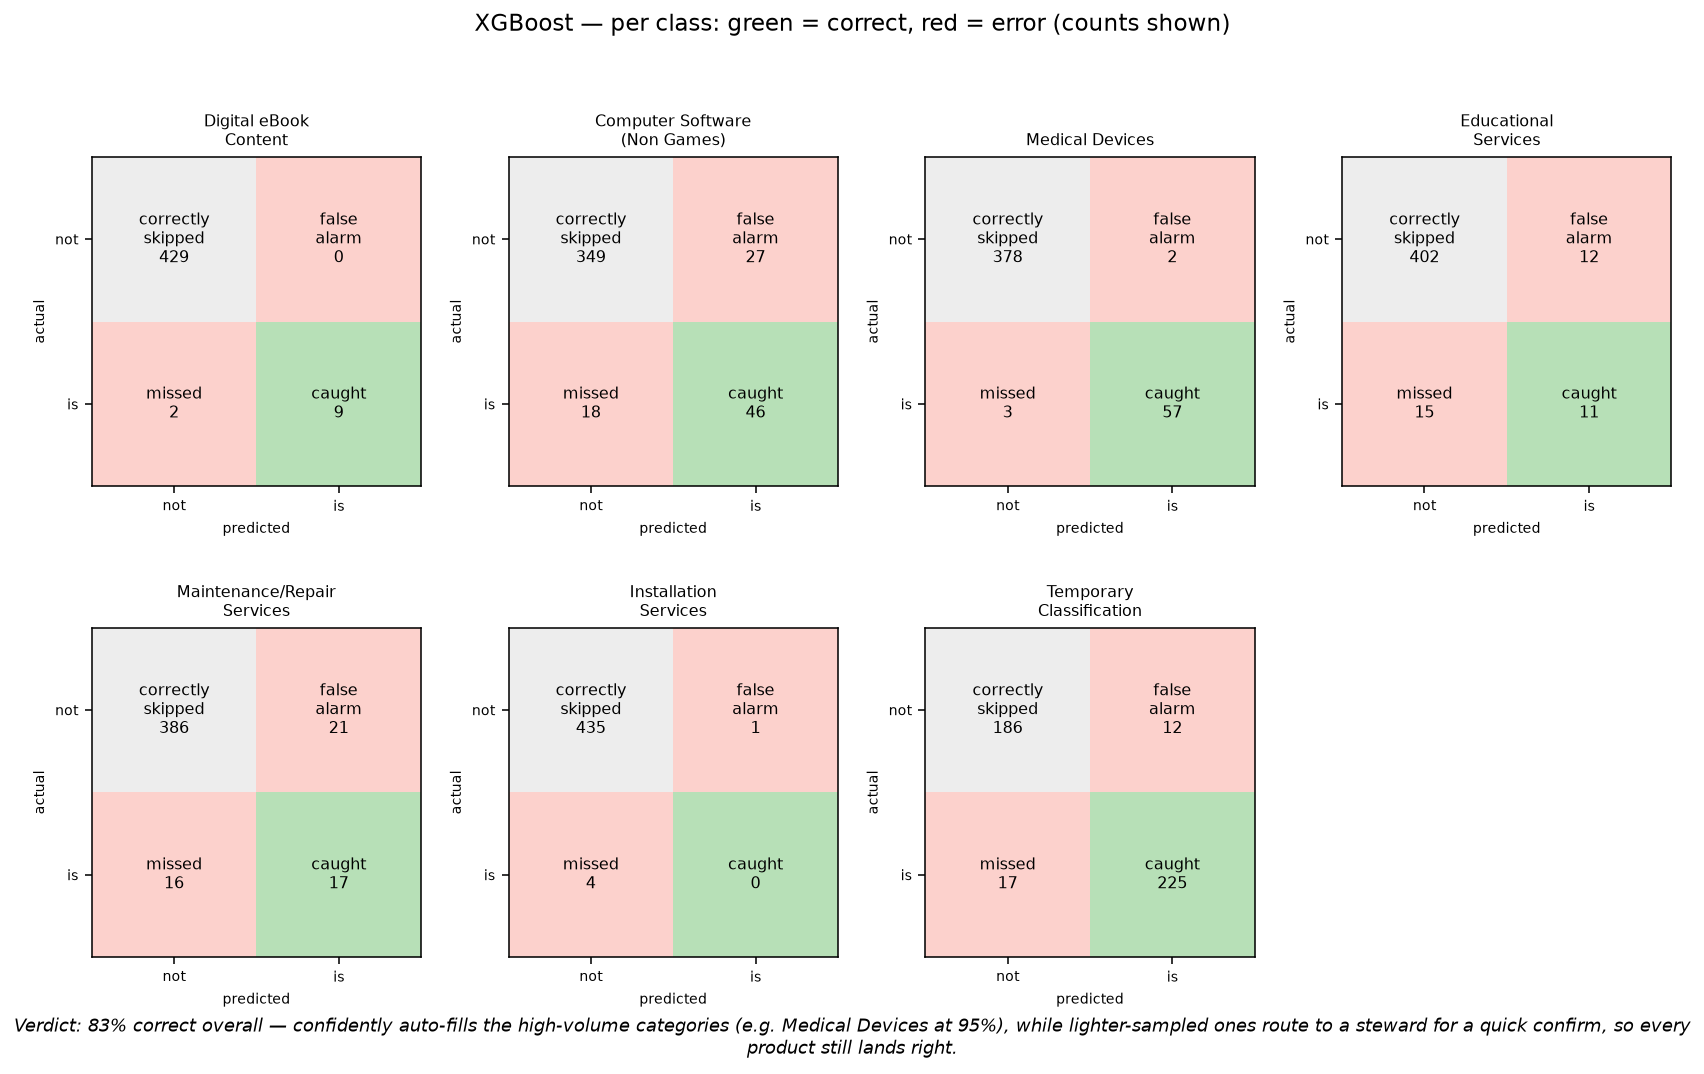

In [7]:
def fit_predict_xgb(train_df, test_df, y_train):
    """Train XGBoost on sparse features; return per-class probs and class names."""
    Xtr, Xte = make_sparse(train_df, test_df); le = LabelEncoder().fit(y_train); ytr = le.transform(y_train)
    m = xgb.XGBClassifier(objective="multi:softprob", num_class=len(le.classes_), n_estimators=400, learning_rate=0.05,
                          max_depth=4, min_child_weight=1.0, subsample=0.8, colsample_bytree=0.5, reg_lambda=1.0,
                          tree_method="hist", random_state=SEED, n_jobs=-1, eval_metric="mlogloss")
    m.fit(Xtr, ytr, sample_weight=compute_sample_weight("balanced", ytr))
    return m.predict_proba(Xte), le.classes_.astype(str)

confusion_fig(fit_predict_xgb, "XGBoost")

MODELS = {"Logistic Regression": fit_predict_lr, "LightGBM": fit_predict_lgbm, "XGBoost": fit_predict_xgb}

## Evaluation - Macro-F1

In [ ]:
rows = []
for target in TARGETS:
    sub, y = get_xy(df, target)
    for name, fp in MODELS.items():
        r = cross_validate(fp, sub, y)
        rows.append(dict(field=target, model=name, macroF1=round(r["macroF1"], 3),
                         top1=round(r["top1"], 3), top3=round(r["top3"], 3)))
res = pd.DataFrame(rows)
(res.pivot(index="model", columns="field", values="macroF1")[TARGETS]
    .style.format("{:.3f}").background_gradient(cmap="Greens", axis=None)
    .set_caption("Macro-F1 by model and field (darker = better; macro-F1 = the fair score on imbalanced data)"))

,GPCBrickCode,ProductType,ProductGroup,ProductFamily,UNSPSCNumber
LightGBM,0.656,0.466,0.629,0.632,0.594
Logistic Regression,0.662,0.505,0.639,0.642,0.594
XGBoost,0.633,0.448,0.599,0.602,0.557


## Drivers of per-field accuracy


<table style="border-collapse:collapse;width:100%;max-width:900px;font-family:-apple-system,Segoe UI,Roboto,sans-serif;font-size:13px;box-shadow:0 1px 4px rgba(0,0,0,.12);border-radius:6px;overflow:hidden;"><thead><tr><th style="padding:9px 13px;background:#37474f;color:#fff;font-weight:600;text-align:left;">Field</th><th style="padding:9px 13px;background:#37474f;color:#fff;font-weight:600;text-align:center;">Categories</th><th style="padding:9px 13px;background:#37474f;color:#fff;font-weight:600;text-align:left;">Data shape</th><th style="padding:9px 13px;background:#37474f;color:#fff;font-weight:600;text-align:center;">Macro-F1</th><th style="padding:9px 13px;background:#37474f;color:#fff;font-weight:600;text-align:left;">Why</th></tr></thead><tbody><tr style="background:#ffffff;"><td style="padding:8px 13px;border-bottom:1px solid #eceff1;font-weight:600;color:#263238;text-align:left;">GPCBrickCode</td><td style="padding:8px 13px;border-bottom:1px solid #eceff1;text-align:center;">7</td><td style="padding:8px 13px;border-bottom:1px solid #eceff1;color:#607d8b;font-size:12px;text-align:left;">440 rows &middot; median 33/class &middot; top 55%</td><td style="padding:8px 13px;border-bottom:1px solid #eceff1;background:#72c076;color:#14532d;font-weight:700;text-align:center;">0.662</td><td style="padding:8px 13px;border-bottom:1px solid #eceff1;color:#37474f;text-align:left;">Few categories, all well stocked. Easiest field.</td></tr><tr style="background:#f5f7fa;"><td style="padding:8px 13px;border-bottom:1px solid #eceff1;font-weight:600;color:#263238;text-align:left;">ProductGroup</td><td style="padding:8px 13px;border-bottom:1px solid #eceff1;text-align:center;">23</td><td style="padding:8px 13px;border-bottom:1px solid #eceff1;color:#607d8b;font-size:12px;text-align:left;">523 rows &middot; median 25/class &middot; top 5%</td><td style="padding:8px 13px;border-bottom:1px solid #eceff1;background:#82c786;color:#14532d;font-weight:700;text-align:center;">0.639</td><td style="padding:8px 13px;border-bottom:1px solid #eceff1;color:#37474f;text-align:left;">Evenly balanced (top class 5%). No starved classes.</td></tr><tr style="background:#ffffff;"><td style="padding:8px 13px;border-bottom:1px solid #eceff1;font-weight:600;color:#263238;text-align:left;">ProductType</td><td style="padding:8px 13px;border-bottom:1px solid #eceff1;text-align:center;">25</td><td style="padding:8px 13px;border-bottom:1px solid #eceff1;color:#607d8b;font-size:12px;text-align:left;">523 rows &middot; median 5/class &middot; top 30%</td><td style="padding:8px 13px;border-bottom:1px solid #eceff1;background:#dff0e1;color:#14532d;font-weight:700;text-align:center;">0.505</td><td style="padding:8px 13px;border-bottom:1px solid #eceff1;color:#37474f;text-align:left;">14 of 25 categories under 6 examples. Thin classes lower the score.</td></tr><tr style="background:#f5f7fa;"><td style="padding:8px 13px;border-bottom:1px solid #eceff1;font-weight:600;color:#263238;text-align:left;">ProductFamily</td><td style="padding:8px 13px;border-bottom:1px solid #eceff1;text-align:center;">70</td><td style="padding:8px 13px;border-bottom:1px solid #eceff1;color:#607d8b;font-size:12px;text-align:left;">523 rows &middot; median 4/class &middot; top 14%</td><td style="padding:8px 13px;border-bottom:1px solid #eceff1;background:#80c683;color:#14532d;font-weight:700;text-align:center;">0.642</td><td style="padding:8px 13px;border-bottom:1px solid #eceff1;color:#37474f;text-align:left;">Well sampled families score; rare ones pool into RARE.</td></tr><tr style="background:#ffffff;"><td style="padding:8px 13px;border-bottom:1px solid #eceff1;font-weight:600;color:#263238;text-align:left;">UNSPSCNumber</td><td style="padding:8px 13px;border-bottom:1px solid #eceff1;text-align:center;">71</td><td style="padding:8px 13px;border-bottom:1px solid #eceff1;color:#607d8b;font-size:12px;text-align:left;">435 rows &middot; median 1/class &middot; top 28%</td><td style="padding:8px 13px;border-bottom:1px solid #eceff1;background:#a1d5a4;color:#14532d;font-weight:700;text-align:center;">0.594</td><td style="padding:8px 13px;border-bottom:1px solid #eceff1;color:#37474f;text-align:left;">Sparsest field (median 1). Frequent codes score; rest go to review.</td></tr></tbody></table>

## Sample handoff payload
The JSON contract the integration team consumes: one object per product, with a suggested value, a confidence and an
action per field. Illustrative only - generic placeholders, no real product data.

```json
{
  "schema_version": "1.0",
  "source": "product-master-data-classifier (in-tenant, no external LLM)",
  "record": { "ProductNumber": "PN-00000",
              "input_text": "<fused product text: short name + functional name + description>" },
  "suggestions": {
    "GPCBrickCode":  { "suggested_value": "10000000 - <category name>", "confidence": 0.97, "action": "AUTOFILL",
                       "alternatives": [ {"value": "10000001 - <alternative category>", "confidence": 0.01} ] },
    "ProductType":   { "suggested_value": "<product type>",   "confidence": 0.79, "action": "AUTOFILL" },
    "ProductGroup":  { "suggested_value": "<product group>",  "confidence": 0.59, "action": "AUTOFILL" },
    "ProductFamily": { "suggested_value": "<product family>", "confidence": 0.61, "action": "AUTOFILL" },
    "UNSPSCNumber":  { "suggested_value": "00000000",         "confidence": 0.59, "action": "AUTOFILL" }
  }
}
```

**How it is used:** the integration team writes `suggested_value` when `confidence >= threshold` (`action: AUTOFILL`),
and routes anything below the threshold (`action: REVIEW`) to a steward.